# **LoRA-адаптер для стиля тату "одной линии"**
(сервис генерации уникальных эскизов тату TattiSketch)

# Инструкция для запуска ноутбука

Этот ноутбук выполняет:
- обучение LoRA-адаптера на датасете из 51-го эскиза тату (выполнены в стиле одной непрерывной линии) с использованием платформы Fal.ai;
- генерацию изображений на baseline-модели с использованием платформы Fal.ai;
- генерацию изображений на обученном LoRA-адаптере с использованием платформы Fal.ai;
- расчет, оценку и визуализацию метрик

**Для корректной работы требуется:**
- установить свой API-ключ Fal.ai через `userdata` или переменную `FAL_KEY`;
- загрузить архив `dataset.zip` с датасетом изображений в папку `/content/` для обучения LoRA-адаптера;
- загрузить референс `sample_line.png` в папку `/content/dataset/` для оценки метрик.

---


## 1. Установка зависимостей

In [ ]:
!pip install fal-client requests Pillow opencv-python matplotlib scikit-image torch torchvision


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 120.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 93.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 104.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

## 2. Импорт библиотек и настройка API


In [ ]:
import fal_client
import requests
import json
import os
import re
import glob
import time
import math
import random
import cv2
import numpy as np
import itertools
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from skimage.measure import label
from scipy.spatial.distance import euclidean
import torch
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from google.colab import userdata
from fal_client import Queued, InProgress, Completed
from IPython.display import display
from PIL import Image, ImageEnhance, ImageDraw
from google.colab.patches import cv2_imshow


## 3. Конфигурация


In [ ]:
!mkdir -p dataset/refs

In [ ]:
FAL_KEY = userdata.get('FAL_API_KEY')
os.environ["FAL_KEY"] = FAL_KEY

# Референс
REF_IMAGE_PATH = "/content/dataset/sample_line.png"


## 4. Создание аугментированных данных

In [ ]:
# Создаем папку для аугментированных данных
os.makedirs('/content/augmented_dataset', exist_ok=True)

In [ ]:
def augment_image(img_path, output_dir):
    # Базовое имя файла
    base_name = os.path.splitext(os.path.basename(img_path))[0]

    # Загрузка изображения
    img = Image.open(img_path)

    # Горизонтальное отражение
    img_flip = img.transpose(Image.FLIP_LEFT_RIGHT)
    img_flip.save(f"{output_dir}/{base_name}_flip.png")

# Обработка всех изображений
for img_file in os.listdir('/content/dataset/refs'):
    if img_file.endswith(('.jpg', '.png', '.jpeg')):
        augment_image(f"/content/dataset/refs/{img_file}", "/content/augmented_dataset")

In [ ]:
# Создаем папку для архивирования
os.makedirs('/content/updated_dataset', exist_ok=True)

In [ ]:
# Копируем оригинальные изображения
!cp -r /content/dataset/refs/* /content/updated_dataset/

In [ ]:
# Добавляем аугментированные изображения
!cp /content/augmented_dataset/* /content/updated_dataset/

In [ ]:
# Создаем архив для загрузки на Fal.ai
!zip -r /content/updated_dataset.zip /content/updated_dataset

  adding: content/updated_dataset/ (stored 0%)
  adding: content/updated_dataset/36.png (deflated 6%)
  adding: content/updated_dataset/29.png (deflated 5%)
  adding: content/updated_dataset/51.png (deflated 4%)
  adding: content/updated_dataset/19.png (deflated 8%)
  adding: content/updated_dataset/19_flip.png (deflated 12%)
  adding: content/updated_dataset/33.png (deflated 5%)
  adding: content/updated_dataset/23.png (deflated 8%)
  adding: content/updated_dataset/11_flip.png (deflated 11%)
  adding: content/updated_dataset/48_flip.png (deflated 10%)
  adding: content/updated_dataset/6_flip.png (deflated 14%)
  adding: content/updated_dataset/36_flip.png (deflated 9%)
  adding: content/updated_dataset/25_flip.png (deflated 13%)
  adding: content/updated_dataset/29_flip.png (deflated 10%)
  adding: content/updated_dataset/2_flip.png (deflated 10%)
  adding: content/updated_dataset/7.png (deflated 7%)
  adding: content/updated_dataset/32.png (deflated 5%)
  adding: content/updated_dat

## 5. Загрузка обновленного датасета на платформу Fal.ai

In [ ]:
data_zip_url = fal_client.upload_file("updated_dataset.zip")
print("ZIP загружен:", data_zip_url)

ZIP загружен: https://v3.fal.media/files/zebra/-JXKSab2HFwO1VAKT37Oh_updated_dataset.zip


## 6. Создание файла подписей jsonl

In [ ]:
# 1. Список ваших изображений и подписей
data = [
    {"file_name": "2.png", "text": "[trigger] air balloon"},
    {"file_name": "2_flip.png", "text": "[trigger] air balloon"},
    {"file_name": "5.png", "text": "[trigger] owl"},
    {"file_name": "5_flip.png", "text": "[trigger] owl"},
    {"file_name": "6.png", "text": "[trigger] flower"},
    {"file_name": "6_flip.png", "text": "[trigger] flower"},
    {"file_name": "7.png", "text": "[trigger] tree"},
    {"file_name": "7_flip.png", "text": "[trigger] tree"},
    {"file_name": "9.png", "text": "[trigger] table lamp"},
    {"file_name": "9_flip.png", "text": "[trigger] table lamp"},
    {"file_name": "11.png", "text": "[trigger] glass"},
    {"file_name": "11_flip.png", "text": "[trigger] glass"},
    {"file_name": "14.png", "text": "[trigger] snail"},
    {"file_name": "14_flip.png", "text": "[trigger] snail"},
    {"file_name": "16.png", "text": "[trigger] candle"},
    {"file_name": "16_flip.png", "text": "[trigger] candle"},
    {"file_name": "17.png", "text": "[trigger] dolphin"},
    {"file_name": "17_flip.png", "text": "[trigger] dolphin"},
    {"file_name": "19.png", "text": "[trigger] swan"},
    {"file_name": "19_flip.png", "text": "[trigger]swan"},
    {"file_name": "22.png", "text": "[trigger] flamingo"},
    {"file_name": "22_flip.png", "text": "[trigger] flamingo"},
    {"file_name": "23.png", "text": "[trigger] stingray fish"},
    {"file_name": "23_flip.png", "text": "[trigger] stingray fish"},
    {"file_name": "24.png", "text": "[trigger] lips"},
    {"file_name": "24_flip.png", "text": "[trigger] lips"},
    {"file_name": "25.png", "text": "[trigger] plane"},
    {"file_name": "25_flip.png", "text": "[trigger] plane"},
    {"file_name": "27.png", "text": "[trigger] elephant"},
    {"file_name": "27_flip.png", "text": "[trigger] elephant"},
    {"file_name": "29.png", "text": "[trigger] rose"},
    {"file_name": "29_flip.png", "text": "[trigger] rose"},
    {"file_name": "32.png", "text": "[trigger] puppy"},
    {"file_name": "32_flip.png", "text": "[trigger] puppy"},
    {"file_name": "33.png", "text": "[trigger] starfish"},
    {"file_name": "33_flip.png", "text": "[trigger] starfish"},
    {"file_name": "34.png", "text": "[trigger] anchor"},
    {"file_name": "34_flip.png", "text": "[trigger] anchor"},
    {"file_name": "35.png", "text": "[trigger] mermaid"},
    {"file_name": "35_flip.png", "text": "[trigger] mermaid"},
    {"file_name": "36.png", "text": "[trigger] sailboat"},
    {"file_name": "36_flip.png", "text": "[trigger] sailboat"},
    {"file_name": "37.png", "text": "[trigger] cat"},
    {"file_name": "37_flip.png", "text": "[trigger] cat"},
    {"file_name": "38.png", "text": "[trigger] seagull"},
    {"file_name": "38_flip.png", "text": "[trigger] seagull"},
    {"file_name": "39.png", "text": "[trigger] turtle"},
    {"file_name": "39_flip.png", "text": "[trigger] turtle"},
    {"file_name": "40.png", "text": "[trigger] hourglass"},
    {"file_name": "40_flip.png", "text": "[trigger] hourglass"},
    {"file_name": "41.png", "text": "[trigger] wolf"},
    {"file_name": "41_flip.png", "text": "[trigger] wolf"},
    {"file_name": "42.png", "text": "[trigger] whale"},
    {"file_name": "42_flip.png", "text": "[trigger] whale"},
    {"file_name": "43.png", "text": "[trigger] heron"},
    {"file_name": "43_flip.png", "text": "[trigger] heron"},
    {"file_name": "46.png", "text": "[trigger] penguin"},
    {"file_name": "46_flip.png", "text": "[trigger] penguin"},
    {"file_name": "47.png", "text": "[trigger] heart"},
    {"file_name": "47_flip.png", "text": "[trigger] heart"},
    {"file_name": "48.png", "text": "[trigger] giraffe"},
    {"file_name": "48_flip.png", "text": "[trigger] giraffe"},
    {"file_name": "50.png", "text": "[trigger] hummingbird"},
    {"file_name": "50_flip.png", "text": "[trigger] hummingbird"},
    {"file_name": "51.png", "text": "[trigger] rabbit"},
    {"file_name": "51_flip.png", "text": "[trigger] rabbit"}
]

# 2. Создание JSONL-файла
with open('captions.jsonl', 'w') as f:
    for item in data:
        f.write(json.dumps(item))  # Преобразуем dict в JSON строку
        f.write('\n')             # Добавляем перевод строки

# 3. Проверка содержимого
!head -n 3 captions.jsonl

{"file_name": "2.png", "text": "[trigger] air balloon"}
{"file_name": "2_flip.png", "text": "[trigger] air balloon"}
{"file_name": "5.png", "text": "[trigger] owl"}


## 7. Загрузка файла подписей jsonl на платформу Fal.ai

In [ ]:
captions_jsonl_url = fal_client.upload_file("captions.jsonl")
print("jsonl загружен:", captions_jsonl_url)

jsonl загружен: https://v3.fal.media/files/panda/WkezBuPQAMF9zi5aM9KeU_captions.jsonl


## 8. Обучение LoRA-адаптера на платформе Fal.ai

In [ ]:
handler = fal_client.submit(
    "fal-ai/flux-lora-general-training",
    arguments={
        "images_data_url": data_zip_url,
        "steps": 2000,
        "captions_file_url": captions_jsonl_url,
        "rank": 64,
        "learning_rate": 0.0004,
        "caption_dropout_rate": 0.05,
        "experimental_optimizers": "adamw8bit",
        "trigger_word": "single_line",
        "create_masks": True
    }
)

while True:
    status = fal_client.status(
        "fal-ai/flux-lora-general-training",
        handler.request_id,
        with_logs=True
    )

    if isinstance(status, Queued):
        print(f"В очереди (position={status.position})")

    elif isinstance(status, InProgress):
        for log in status.logs or []:
            print(log.get("message", "<no message>"))

    elif isinstance(status, Completed):
        print("Обучение завершено!")
        break

    else:
        raise RuntimeError(f"Unexpected status object: {status!r}")

    time.sleep(30)

result = fal_client.result("fal-ai/flux-lora-general-training", handler.request_id)
lora_url = result["diffusers_lora_file"]["url"]
print("LoRA weights:", lora_url)


Выходные данные были обрезаны до нескольких последних строк (5000).
lora:  80%|███████▉  | 1599/2000 [20:09<04:55,  1.36it/s, lr: 4.0e-04 loss: 5.234e-02]
Generating Images: 0it [00:00, ?it/s]
                                     
lora:  85%|████████▍ | 1699/2000 [21:25<03:42,  1.35it/s, lr: 4.0e-04 loss: 4.379e-02]
Generating Images: 0it [00:00, ?it/s]
                                     
lora:  75%|███████▍  | 1499/2000 [18:53<06:06,  1.37it/s, lr: 4.0e-04 loss: 4.724e-02]
Generating Images: 0it [00:00, ?it/s]
                                     
lora:  80%|███████▉  | 1599/2000 [20:09<04:55,  1.36it/s, lr: 4.0e-04 loss: 5.234e-02]
Generating Images: 0it [00:00, ?it/s]
                                     
lora:  85%|████████▍ | 1699/2000 [21:25<03:42,  1.35it/s, lr: 4.0e-04 loss: 4.379e-02]
Generating Images: 0it [00:00, ?it/s]
                                     
lora:  90%|████████▉ | 1799/2000 [22:40<02:25,  1.39it/s, lr: 4.0e-04 loss: 1.770e-01]
Generating Images: 0it [00:00,

Файл весов обученного LoRA-адаптера (`"steps": 2000`):

In [ ]:
lora_url = "https://v3.fal.media/files/kangaroo/1FNHuASaCYOwCQ8jw3zvx_lora.safetensors"

In [ ]:
TRIG  = "<single_line>"

## 9. Генерация изображений

In [42]:
#MODEL = "fal-ai/flux-lora"
MODEL = "fal-ai/flux-general"
LORA  = lora_url

def generate(prompt, use_lora=False):
    seed = random.randint(1, 1_000_000_000)

    # Формируем основной текст промпта
    main_prompt = (
        f"{prompt}"
        #"clean and sharp outlines optimized for tattoo sketch, "
        #"strong contrast and clear readability. "
    )

    args = {
        # Добавляем в prompt триггер
        "prompt": f"{TRIG} depicting {main_prompt}" if use_lora else main_prompt,
        "negative_prompt": (
            "filling, painting, pencil shading, grayscale shading, "
            "color gradients, blurred edges, gray background, colour background"
        ),
        "image_size": { "width": 512, "height": 512 },
        "num_inference_steps": 44,
        "guidance_scale": 5.8,
        "seed": seed
    }

    if use_lora:
        args["loras"] = [{ "path": LORA, "scale": 1.0 }]

    result = fal_client.run(MODEL, arguments=args)
    url = result["images"][0]["url"]
    return Image.open(requests.get(url, stream=True).raw).convert("RGB")


# Директория для сохранения
os.makedirs("generated/lora_imp",     exist_ok=True)

# Список популярных тату
object_list = [
    "skull", "rose", "anchor", "rat", "cat", "wolf", "moon", "gun",
    "lion", "feather", "sun", "heart", "fish", "bird", "mountain", "tree",
    "diamond", "yoga", "clock", "flower", "dreamcatcher", "butterfly",
    "compass", "wave", "owl", "snake", "dragon", "crown", "arrow", "star"
]

prompts = random.sample(object_list, 2)

for i, p in enumerate(prompts):
    img_lora = generate(p, use_lora=True)
    img_lora.save(f"generated/lora_imp/lora_imp_{i}.png")


## 10. Визуализация сгенерированных результатов и референса

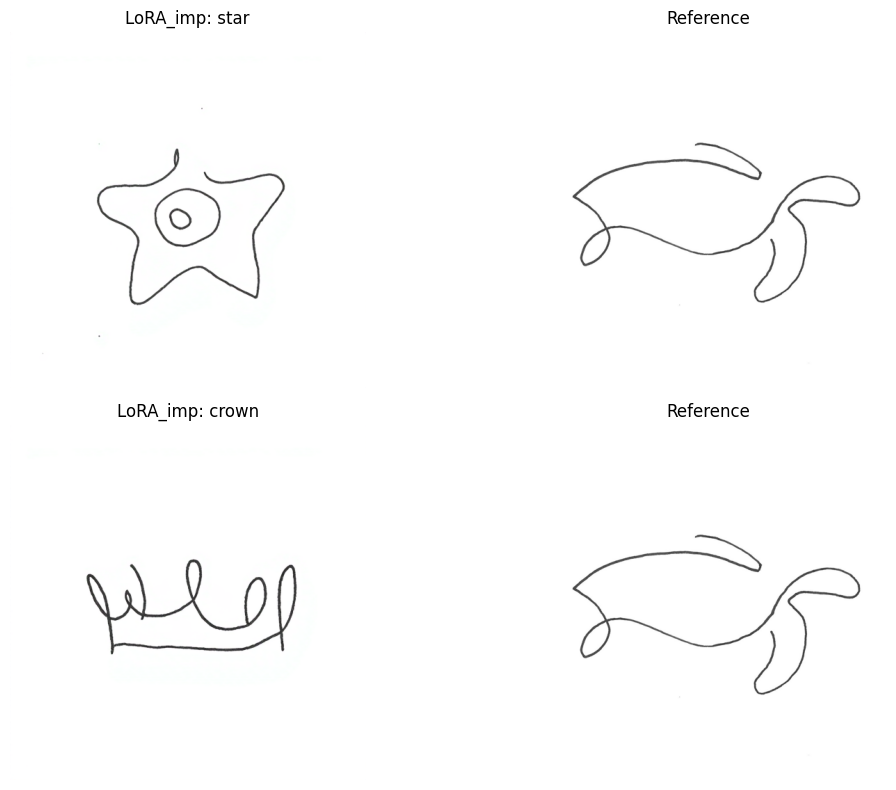

In [43]:
fig, ax_img = plt.subplots(len(prompts), 2, figsize=(12, 4 * len(prompts)))

for i, p in enumerate(prompts):
    img_l = Image.open(f"generated/lora_imp/lora_imp_{i}.png")
    img_r = Image.open(REF_IMAGE_PATH)

    ax_img[i, 0].imshow(img_l)
    ax_img[i, 0].set_title(f"LoRA_imp: {p}")
    ax_img[i, 0].axis("off")

    ax_img[i, 1].imshow(img_r)
    ax_img[i, 1].set_title("Reference")
    ax_img[i, 1].axis("off")

plt.tight_layout()
plt.show()


In [45]:
from io import BytesIO

MODEL = "fal-ai/flux-general"
LORA = lora_url
NUM_IMAGES = 2

def generate_multiple(prompt, use_lora=False, num_images=NUM_IMAGES):
    seed = random.randint(1, 1_000_000_000)

    main_prompt = f"{prompt}, line art, continuous stroke, black and white"

    args = {
        "prompt": f"{TRIG} {main_prompt}" if use_lora else main_prompt,
        "negative_prompt": (
            "filling, painting, shading, gradients, "
            "blurred edges, background, colors"
        ),
        "image_size": {"width": 512, "height": 512},
        "num_inference_steps": 46,
        "guidance_scale": 5.0,
        "seed": seed,
        "num_images": num_images,
        "output_format": "png"
    }

    if use_lora:
        args["loras"] = [{"path": LORA, "scale": 1.0}]

    try:
        result = fal_client.run(MODEL, arguments=args)
        images = []

        for i, image_data in enumerate(result["images"]):
            img_url = image_data["url"]
            response = requests.get(img_url, stream=True)
            response.raise_for_status()
            img = Image.open(BytesIO(response.content)).convert("RGB")
            images.append(img)

        return images

    except Exception as e:
        print(f"Ошибка генерации: {str(e)}")
        return []

# Создаем директории
os.makedirs("generated/multi_output", exist_ok=True)

# Список объектов для генерации
object_list = [
    "skull", "rose", "anchor", "rat", "cat", "wolf", "moon", "gun",
    "lion", "feather", "sun", "heart", "fish", "bird", "mountain", "tree",
    "diamond", "yoga", "clock", "flower", "dreamcatcher", "butterfly",
    "compass", "wave", "owl", "snake", "dragon", "crown", "arrow", "star"
]

# Генерируем для 2 случайных промптов
prompts = random.sample(object_list, 2)

for prompt in prompts:
    print(f"\nГенерация для: {prompt}")
    images = generate_multiple(prompt, use_lora=True)

    for i, img in enumerate(images):
        filename = f"generated/multi_output/{prompt}_{i}.png"
        img.save(filename)
        print(f"Сохранено: {filename}")



Генерация для: dreamcatcher
Сохранено: generated/multi_output/dreamcatcher_0.png
Сохранено: generated/multi_output/dreamcatcher_1.png

Генерация для: star
Сохранено: generated/multi_output/star_0.png
Сохранено: generated/multi_output/star_1.png
